# 05 - LLM Generation Evaluation (GPT-5.5 vs QLoRA Qwen)

Phase 7.5. Two-model raw generation comparison (no RAG, no MASS-RAG) on a stratified 100-pair sample from `data/qlora_training/test.jsonl`. Two complementary metrics:

- **ROUGE-1 / ROUGE-2 / ROUGE-L** (F1, Porter stemmer) — surface n-gram overlap.
- **BERTScore** (P / R / F1) - semantic similarity via contextual embeddings, backbone = `microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext` (medical-tuned).

**Why both:** ROUGE rewards style/template mimicry (which the QLoRA fine-tune learned); BERTScore rewards semantic correctness (where GPT-5.5 should plausibly win). Reporting both makes the trade-off visible.

**Models compared**

1. **GPT-5.5** - Responses API
2. **QLoRA Qwen** - Qwen2.5-1.5B-Instruct + QLoRA adapter, served as `medqa-qwen` via Ollama (`model_choice="local"`)

**Setup:** raw generation, no RAG, no MASS-RAG; identical system prompt for both; cloud call first per row.

**Caching:** each stage (generation -> ROUGE -> BERTScore) checks the existing `results/llm_generation_evaluation.csv` and skips if its columns are present. Set `FORCE_REGENERATE = True` to bypass.

**Outputs**

- `results/llm_generation_evaluation.csv` - long format, one row per (test_pair, model), with ROUGE + BERTScore columns
- `results/llm_generation_evaluation.md` - overall + per-source × model breakdown
- `results/llm_generation_eval_chart.png` - ROUGE-L by source × model
- `results/llm_generation_bertscore_chart.png` - BERTScore-F1 by source × model


In [1]:
from __future__ import annotations

import json
import random
import sys
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

# add project root to sys.path so src.* imports work when running from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.pipeline import llm  # noqa: E402

TEST_FILE = PROJECT_ROOT / "data" / "qlora_training" / "test.jsonl"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
CSV_PATH = RESULTS_DIR / "llm_generation_evaluation.csv"

SAMPLE_N = 100
SEED = 42
WARM = "#c47a4d"  # GPT-5.5
COOL = "#3b6e8f"  # QLoRA Qwen

MODELS = [
    {"name": "GPT-5.5", "model_choice": "cloud", "color": WARM},
    {"name": "QLoRA Qwen", "model_choice": "local", "color": COOL},
]

# Toggles. Flip to True to ignore the cache and re-run a stage.
FORCE_REGENERATE = False  # re-call the LLMs
FORCE_RESCORE_ROUGE = False  # re-compute ROUGE on existing generations
FORCE_RESCORE_BERT = False  # re-compute BERTScore on existing generations

# BERTScore backbone (medical-tuned). PubMedBERT-base is a 12-layer model; we pick
# layer 9 — a common compromise for base-BERT-style backbones in BERTScore.
BERT_MODEL = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
BERT_NUM_LAYERS = 9

## 0. Ollama sanity check (only if we'll regenerate)

Confirms the local model is reachable before we start a long generation loop. Skipped when the CSV cache hits — no point pinging Ollama if we won't be calling it.


In [2]:
_will_regenerate = FORCE_REGENERATE or not CSV_PATH.exists()
if not _will_regenerate:
    print("CSV cache present — skipping Ollama check (no generation will run).")
else:
    from src.utils.config import LOCAL_MODEL_NAME, OLLAMA_BASE_URL
    import requests

    try:
        tags = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5).json()
        served = {m["name"].split(":")[0] for m in tags.get("models", [])}
        assert (
            LOCAL_MODEL_NAME in served
        ), f"{LOCAL_MODEL_NAME!r} not in Ollama tags: {served}"
        print(f"Ollama OK — serving: {sorted(served)} (using {LOCAL_MODEL_NAME!r})")
    except Exception as e:
        raise RuntimeError(
            f"Ollama not reachable at {OLLAMA_BASE_URL}. "
            f"Start the Ollama daemon and `ollama create medqa-qwen -f models/qwen-medqa-gguf/Modelfile`. "
            f"Original error: {e}"
        )

CSV cache present — skipping Ollama check (no generation will run).


## 1. Load test set + stratified sample

Bucket by `source`, take `SAMPLE_N // n_sources` per bucket, then round-robin a few extras from the first buckets to hit exactly 100. Deterministic with `seed=42`. Always runs (cheap).


In [3]:
with TEST_FILE.open(encoding="utf-8") as f:
    test_pairs = [json.loads(line) for line in f if line.strip()]

by_source: dict[str, list[dict]] = defaultdict(list)
for row in test_pairs:
    by_source[row["source"]].append(row)

rng = random.Random(SEED)
for src in by_source:
    rng.shuffle(by_source[src])

sources = sorted(by_source)
per_source = SAMPLE_N // len(sources)
leftover = SAMPLE_N - per_source * len(sources)

sample: list[dict] = []
for i, src in enumerate(sources):
    take = per_source + (1 if i < leftover else 0)
    sample.extend(by_source[src][:take])

rng.shuffle(sample)
print(f"Total test pairs: {len(test_pairs)}")
print(f"Sample size:      {len(sample)}")
src_counts = pd.Series([r["source"] for r in sample]).value_counts().sort_index()
src_counts

Total test pairs: 450
Sample size:      100


bioasq                          17
drugbank-description            17
drugbank-indication             17
drugbank-mechanism_of_action    17
drugbank-side_effects           16
medquad                         16
Name: count, dtype: int64

## 2. Generate with both models

If `results/llm_generation_evaluation.csv` already has both models × all 100 pairs, the loop is skipped and the cached `df` is reused. Otherwise: identical single-turn system prompt for both, cloud call first then local. Set `FORCE_REGENERATE = True` to override.


In [4]:
SYSTEM = (
    "You are a concise medical question-answering assistant. "
    "Answer the user's question directly and accurately in 1-3 short paragraphs. "
    "Do not add disclaimers, do not ask follow-up questions, do not list bullet points unless the question explicitly calls for a list."
)

REQUIRED_COLS = {
    "idx",
    "source",
    "model",
    "question",
    "reference",
    "generated",
    "latency_s",
    "error",
}
EXPECTED_ROWS = SAMPLE_N * len(MODELS)


def _csv_cache_complete() -> bool:
    if not CSV_PATH.exists():
        return False
    head = pd.read_csv(CSV_PATH, nrows=1)
    if not REQUIRED_COLS.issubset(head.columns):
        return False
    n = sum(1 for _ in open(CSV_PATH, encoding="utf-8")) - 1
    return n >= EXPECTED_ROWS


if (not FORCE_REGENERATE) and _csv_cache_complete():
    df = pd.read_csv(CSV_PATH)
    df["error"] = df["error"].fillna("")
    print(f"✓ Loaded {len(df)} rows from CSV cache — skipping generation.")
else:
    print(
        f"→ Regenerating ({SAMPLE_N} pairs × {len(MODELS)} models = {EXPECTED_ROWS} calls)…"
    )

    def call_model(prompt: str, model_choice: str) -> tuple[str, float, str]:
        t0 = time.perf_counter()
        try:
            text = llm.generate(prompt=prompt, system=SYSTEM, model_choice=model_choice)
            err = ""
        except Exception as e:
            text = ""
            err = f"{type(e).__name__}: {e}"
        return text, time.perf_counter() - t0, err

    rows = []
    for i, pair in enumerate(tqdm(sample, desc="generate")):
        msgs = pair["messages"]
        question = next(m["content"] for m in msgs if m["role"] == "user")
        reference = next(m["content"] for m in msgs if m["role"] == "assistant")
        for m in MODELS:
            generated, latency, err = call_model(question, m["model_choice"])
            rows.append(
                {
                    "idx": i,
                    "source": pair["source"],
                    "model": m["name"],
                    "question": question,
                    "reference": reference,
                    "generated": generated,
                    "latency_s": latency,
                    "error": err,
                }
            )
    df = pd.DataFrame(rows)
    df.to_csv(CSV_PATH, index=False, encoding="utf-8")
    print(f"Wrote {CSV_PATH} ({len(df)} rows)")

print("\nErrors per model:")
print(df.groupby("model")["error"].apply(lambda s: (s != "").sum()))
print("\nLatency mean per model (s):")
print(df.groupby("model")["latency_s"].mean().round(2))

✓ Loaded 200 rows from CSV cache — skipping generation.

Errors per model:
model
GPT-5.5       0
QLoRA Qwen    0
Name: error, dtype: int64

Latency mean per model (s):
model
GPT-5.5       8.23
QLoRA Qwen    0.90
Name: latency_s, dtype: float64


## 3. ROUGE-1 / ROUGE-2 / ROUGE-L

Lowercase + Porter stemmer. F-measure only. Skipped if `rougeL_f` is already a column. Set `FORCE_RESCORE_ROUGE = True` to override.


In [5]:
ROUGE_COLS = ["rouge1_f", "rouge2_f", "rougeL_f"]

if (not FORCE_RESCORE_ROUGE) and set(ROUGE_COLS).issubset(df.columns):
    print(f"✓ ROUGE columns present — skipping scoring.")
else:
    print("→ Scoring ROUGE…")
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

    def score_row(ref: str, hyp: str) -> dict:
        if not (str(hyp) if hyp is not None else "").strip():
            return {"rouge1_f": 0.0, "rouge2_f": 0.0, "rougeL_f": 0.0}
        s = scorer.score(str(ref), str(hyp))
        return {
            "rouge1_f": s["rouge1"].fmeasure,
            "rouge2_f": s["rouge2"].fmeasure,
            "rougeL_f": s["rougeL"].fmeasure,
        }

    scored = df.apply(
        lambda r: score_row(r["reference"], r["generated"]),
        axis=1,
        result_type="expand",
    )
    df = df.drop(columns=[c for c in ROUGE_COLS if c in df.columns])
    df = pd.concat([df, scored], axis=1)
    df.to_csv(CSV_PATH, index=False, encoding="utf-8")
    print(f"Wrote ROUGE columns to {CSV_PATH}")

df.groupby("model")[["rouge1_f", "rouge2_f", "rougeL_f", "latency_s"]].mean().round(4)

✓ ROUGE columns present — skipping scoring.


,rouge1_f,rouge2_f,rougeL_f,latency_s
model,,,,
GPT-5.5,0.2847,0.0867,0.1877,8.2256
QLoRA Qwen,0.2967,0.1077,0.2095,0.9005


## 3b. BERTScore (PubMedBERT backbone)

Contextual-embedding similarity between generated and reference. Backbone: `microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext` (medical-tuned, 12-layer, layer 9). First run downloads ~440 MB from HuggingFace; ~30 s on GPU, ~2 min on CPU for 200 rows.

Skipped if `bertscore_f1` is already a column. Set `FORCE_RESCORE_BERT = True` to override.


In [6]:
BERT_COLS = ["bertscore_p", "bertscore_r", "bertscore_f1"]

if (not FORCE_RESCORE_BERT) and set(BERT_COLS).issubset(df.columns):
    print(f"✓ BERTScore columns present — skipping scoring.")
else:
    print("→ Scoring BERTScore (PubMedBERT)…")
    import torch
    import transformers
    from bert_score import score as bert_score_fn

    # PubMedBERT's tokenizer_config.json sets model_max_length to a sentinel
    # (~1e30) meaning 'no limit'. bert_score later converts that to a fixed-
    # width C int and raises `OverflowError: int too big to convert`. Patch
    # AutoTokenizer.from_pretrained to clamp the sentinel to 512 (the real
    # max-position for BERT-base) before bert_score loads the tokenizer.
    _orig_from_pretrained = transformers.AutoTokenizer.from_pretrained

    def _safe_from_pretrained(*args, **kwargs):
        tok = _orig_from_pretrained(*args, **kwargs)
        if getattr(tok, "model_max_length", 0) > 1_000_000:
            tok.model_max_length = 512
        return tok

    transformers.AutoTokenizer.from_pretrained = _safe_from_pretrained

    device = "cuda" if torch.cuda.is_available() else "cpu"
    cands = df["generated"].fillna("").astype(str).tolist()
    refs = df["reference"].fillna("").astype(str).tolist()

    try:
        P, R, F1 = bert_score_fn(
            cands=cands,
            refs=refs,
            model_type=BERT_MODEL,
            num_layers=BERT_NUM_LAYERS,
            lang="en",
            verbose=True,
            device=device,
            batch_size=16,
            rescale_with_baseline=False,
        )
    finally:
        transformers.AutoTokenizer.from_pretrained = _orig_from_pretrained

    df = df.drop(columns=[c for c in BERT_COLS if c in df.columns])
    df["bertscore_p"] = P.cpu().numpy()
    df["bertscore_r"] = R.cpu().numpy()
    df["bertscore_f1"] = F1.cpu().numpy()
    df.to_csv(CSV_PATH, index=False, encoding="utf-8")
    print(f"Wrote BERTScore columns to {CSV_PATH} (device={device})")

df.groupby("model")[["rougeL_f", "bertscore_f1", "latency_s"]].mean().round(4)

✓ BERTScore columns present — skipping scoring.


,rougeL_f,bertscore_f1,latency_s
model,,,
GPT-5.5,0.1877,0.8214,8.2256
QLoRA Qwen,0.2095,0.8281,0.9005


## 4. Per-source × model breakdown


In [7]:
agg = (
    df.groupby(["source", "model"])
    .agg(
        n=("idx", "count"),
        rouge1=("rouge1_f", "mean"),
        rouge2=("rouge2_f", "mean"),
        rougeL=("rougeL_f", "mean"),
        bertF1=("bertscore_f1", "mean"),
        latency=("latency_s", "mean"),
    )
    .round(4)
    .reset_index()
)

overall = (
    df.groupby("model")
    .agg(
        n=("idx", "count"),
        rouge1=("rouge1_f", "mean"),
        rouge2=("rouge2_f", "mean"),
        rougeL=("rougeL_f", "mean"),
        bertF1=("bertscore_f1", "mean"),
        latency=("latency_s", "mean"),
    )
    .round(4)
    .reset_index()
)
overall.insert(0, "source", "OVERALL")

agg_full = pd.concat([agg, overall], ignore_index=True)
agg_full

,source,model,n,rouge1,rouge2,rougeL,bertF1,latency
0,bioasq,GPT-5.5,17,0.3016,0.1139,0.2174,0.8333,11.4992
1,bioasq,QLoRA Qwen,17,0.2856,0.0932,0.1995,0.8325,0.6876
2,drugbank-description,GPT-5.5,17,0.3287,0.1089,0.2223,0.8269,6.2233
3,drugbank-description,QLoRA Qwen,17,0.3758,0.1661,0.2682,0.8401,0.9800
4,drugbank-indication,GPT-5.5,17,0.2752,0.1027,0.1970,0.8271,5.8822
5,drugbank-indication,QLoRA Qwen,17,0.2942,0.1154,0.2098,0.8265,0.8782
6,drugbank-mechanism_of_action,GPT-5.5,17,0.3333,0.0840,0.2023,0.8300,6.8109
7,drugbank-mechanism_of_action,QLoRA Qwen,17,0.2813,0.0615,0.1830,0.8198,0.9489
8,drugbank-side_effects,GPT-5.5,16,0.1504,0.0155,0.0939,0.7963,7.3782
9,drugbank-side_effects,QLoRA Qwen,16,0.2432,0.0712,0.1673,0.8184,1.0375


## 5. Best / worst examples per model (by ROUGE-L and BERTScore-F1)


In [8]:
def truncate(s: str, n: int = 200) -> str:
    s = (str(s) if s is not None else "").replace("\n", " ")
    return s if len(s) <= n else s[:n] + " […]"


for m in MODELS:
    sub = df[df["model"] == m["name"]]
    print(f"=== {m['name']} ===")
    print("-- TOP 3 by ROUGE-L --")
    for _, r in sub.nlargest(3, "rougeL_f").iterrows():
        print(
            f"[{r['source']}] ROUGE-L={r['rougeL_f']:.3f} BERT-F1={r['bertscore_f1']:.3f}"
        )
        print(f"  Q:   {truncate(r['question'])}")
        print(f"  REF: {truncate(r['reference'])}")
        print(f"  GEN: {truncate(r['generated'])}\n")
    print("-- TOP 3 by BERTScore-F1 --")
    for _, r in sub.nlargest(3, "bertscore_f1").iterrows():
        print(
            f"[{r['source']}] BERT-F1={r['bertscore_f1']:.3f} ROUGE-L={r['rougeL_f']:.3f}"
        )
        print(f"  Q:   {truncate(r['question'])}")
        print(f"  REF: {truncate(r['reference'])}")
        print(f"  GEN: {truncate(r['generated'])}\n")
    print("-- BOTTOM 3 by BERTScore-F1 --")
    for _, r in sub.nsmallest(3, "bertscore_f1").iterrows():
        print(
            f"[{r['source']}] BERT-F1={r['bertscore_f1']:.3f} ROUGE-L={r['rougeL_f']:.3f}"
        )
        print(f"  Q:   {truncate(r['question'])}")
        print(f"  REF: {truncate(r['reference'])}")
        print(f"  GEN: {truncate(r['generated'])}\n")

=== GPT-5.5 ===
-- TOP 3 by ROUGE-L --
[drugbank-indication] ROUGE-L=0.429 BERT-F1=0.896
  Q:   What is Osilodrostat used for?
  REF: Osilodrostat is indicated for the treatment of adult patients with Cushing's disease for whom pituitary surgery is not an option or has not been curative.
  GEN: Osilodrostat is used to treat excess cortisol production in adults with endogenous Cushing’s syndrome, especially Cushing’s disease when pituitary surgery is not possible or has not been effective.  I […]

[medquad] ROUGE-L=0.378 BERT-F1=0.893
  Q:   How many people are affected by prekallikrein deficiency ?
  REF: The prevalence of prekallikrein deficiency is unknown. Approximately 80 affected individuals in about 30 families have been described in the medical literature. Because prekallikrein deficiency usuall […]
  GEN: Prekallikrein deficiency is extremely rare. Its exact prevalence is unknown, but fewer than about 100 affected families/cases have been reported in the medical literature worl

## 6. Charts - ROUGE-L and BERTScore-F1 by source × model


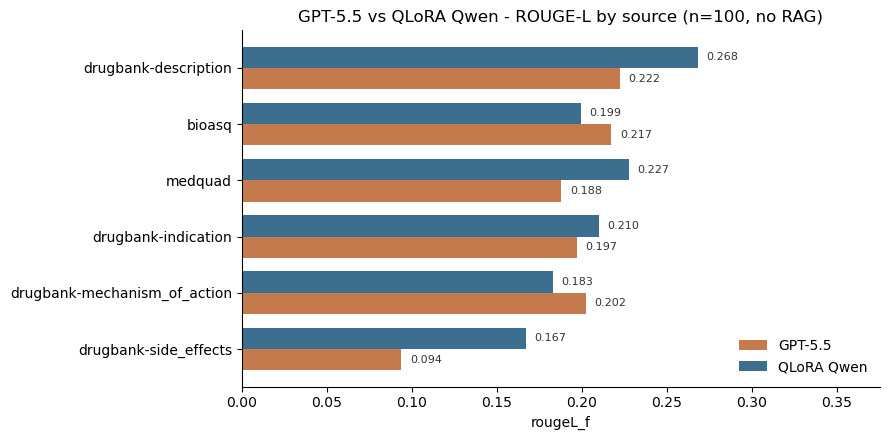

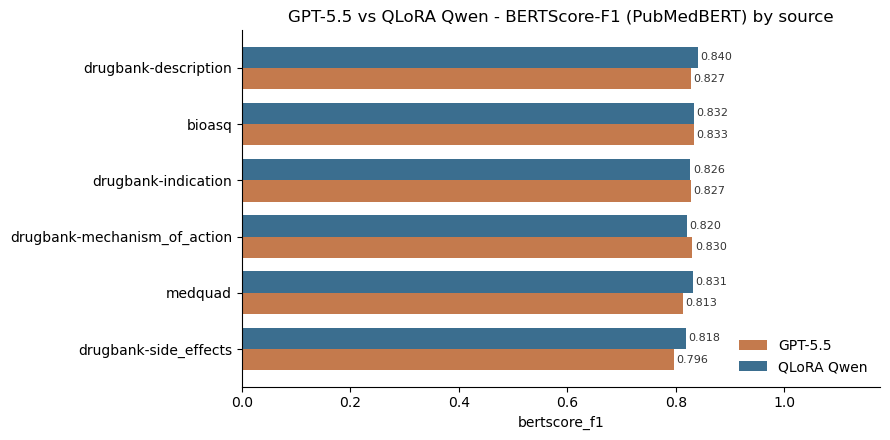

In [13]:
def grouped_bar_chart(metric_col: str, title: str, out_path: Path) -> None:
    pivot = (
        df.groupby(["source", "model"])[metric_col]
        .mean()
        .unstack("model")[[m["name"] for m in MODELS]]
    )
    src_order = pivot.mean(axis=1).sort_values().index.tolist()
    pivot = pivot.loc[src_order]

    y = np.arange(len(pivot.index))
    h = 0.38
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for offset, m in zip([-h / 2, h / 2], MODELS):
        vals = pivot[m["name"]].values
        ax.barh(
            y + offset, vals, h, color=m["color"], edgecolor="none", label=m["name"]
        )
        for yi, v in zip(y + offset, vals):
            ax.text(v + 0.005, yi, f"{v:.3f}", va="center", fontsize=8, color="#333")

    ax.set_yticks(y)
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel(metric_col)
    ax.set_title(title)
    # Headroom on the right so the upper-right legend doesn't sit on top of
    # the longest bar (the topmost source — rows are sorted ascending by mean).
    ax.set_xlim(0, max(pivot.max().max() * 1.40, 0.25))
    ax.legend(loc="lower right", frameon=False)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()


grouped_bar_chart(
    "rougeL_f",
    "GPT-5.5 vs QLoRA Qwen - ROUGE-L by source (n=100, no RAG)",
    RESULTS_DIR / "llm_generation_eval_chart.png",
)
grouped_bar_chart(
    "bertscore_f1",
    "GPT-5.5 vs QLoRA Qwen - BERTScore-F1 (PubMedBERT) by source",
    RESULTS_DIR / "llm_generation_bertscore_chart.png",
)

## 7. Write Markdown report

CSV is already up-to-date (each stage above wrote it as soon as it computed). This cell only writes the human-readable summary.


In [10]:
md_path = RESULTS_DIR / "llm_generation_evaluation.md"

lines = [
    "# LLM Generation Evaluation — GPT-5.5 vs QLoRA Qwen",
    "",
    f"- **Run date**: {time.strftime('%Y-%m-%d %H:%M:%S')}",
    "- **Models**: GPT-5.5 (cloud, `MODEL_GENERATION`) vs QLoRA Qwen (local, Ollama `medqa-qwen`)",
    "- **Test source**: `data/qlora_training/test.jsonl` (450 pairs)",
    f"- **Sample**: {df['idx'].nunique()} stratified by `source` (seed={SEED})",
    f"- **Metrics**: ROUGE-1 / ROUGE-2 / ROUGE-L (F1, Porter stemmer) + BERTScore (P/R/F1, backbone = `{BERT_MODEL}`, layer {BERT_NUM_LAYERS})",
    "- **Setup**: raw generation, no RAG, no MASS-RAG; identical system prompt for both models; cloud call first per row",
    "",
    "## Overall",
    "",
    "| Model | n | ROUGE-1 | ROUGE-2 | ROUGE-L | BERTScore-F1 | Latency (s) | Errors |",
    "|---|---:|---:|---:|---:|---:|---:|---:|",
]
for m in MODELS:
    sub = df[df["model"] == m["name"]]
    lines.append(
        f"| {m['name']} | {len(sub)} | "
        f"{sub['rouge1_f'].mean():.4f} | {sub['rouge2_f'].mean():.4f} | {sub['rougeL_f'].mean():.4f} | "
        f"{sub['bertscore_f1'].mean():.4f} | "
        f"{sub['latency_s'].mean():.2f} | {(sub['error'] != '').sum()} |"
    )

lines += [
    "",
    "## Per-source × model means",
    "",
    "| Source | Model | n | ROUGE-1 | ROUGE-2 | ROUGE-L | BERTScore-F1 | Latency (s) |",
    "|---|---|---:|---:|---:|---:|---:|---:|",
]
for _, r in agg.iterrows():
    lines.append(
        f"| {r['source']} | {r['model']} | {int(r['n'])} | "
        f"{r['rouge1']:.4f} | {r['rouge2']:.4f} | {r['rougeL']:.4f} | "
        f"{r['bertF1']:.4f} | {r['latency']:.2f} |"
    )

lines += [
    "",
    "## Charts",
    "",
    "### ROUGE-L by source × model",
    "![ROUGE-L by source × model](llm_generation_eval_chart.png)",
    "",
    "### BERTScore-F1 by source × model (PubMedBERT)",
    "![BERTScore-F1 by source × model](llm_generation_bertscore_chart.png)",
    "",
]

for m in MODELS:
    sub = df[df["model"] == m["name"]]
    lines += [f"## {m['name']} — top/bottom 3", ""]
    lines += ["**Top 3 by ROUGE-L**", ""]
    for _, r in sub.nlargest(3, "rougeL_f").iterrows():
        lines += [
            f"**[{r['source']}] ROUGE-L = {r['rougeL_f']:.3f} · BERT-F1 = {r['bertscore_f1']:.3f}**",
            f"- Q: {truncate(r['question'], 300)}",
            f"- REF: {truncate(r['reference'], 400)}",
            f"- GEN: {truncate(r['generated'], 400)}",
            "",
        ]
    lines += ["**Top 3 by BERTScore-F1**", ""]
    for _, r in sub.nlargest(3, "bertscore_f1").iterrows():
        lines += [
            f"**[{r['source']}] BERT-F1 = {r['bertscore_f1']:.3f} · ROUGE-L = {r['rougeL_f']:.3f}**",
            f"- Q: {truncate(r['question'], 300)}",
            f"- REF: {truncate(r['reference'], 400)}",
            f"- GEN: {truncate(r['generated'], 400)}",
            "",
        ]
    lines += ["**Bottom 3 by BERTScore-F1**", ""]
    for _, r in sub.nsmallest(3, "bertscore_f1").iterrows():
        lines += [
            f"**[{r['source']}] BERT-F1 = {r['bertscore_f1']:.3f} · ROUGE-L = {r['rougeL_f']:.3f}**",
            f"- Q: {truncate(r['question'], 300)}",
            f"- REF: {truncate(r['reference'], 400)}",
            f"- GEN: {truncate(r['generated'], 400)}",
            "",
        ]

md_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote to files")
print(f"CSV saved")

Wrote to files
CSV saved
